# Lecture 26: Existence and Uniqueness of Moment Maps

**Verified source span.** Lecture 26 starts on physical PDF page 172 and ends on physical PDF page 176, corresponding to printed pages 162-166. The earlier inventory range 176-181 lands on the end of Lecture 26 and then Lecture 27, so this notebook records the corrected span from direct `pdftotext` output.

**Chapter goal.** Turn the question "when does a symplectic infinitesimal action integrate to an equivariant moment map, and how unique is it?" into three inspectable tests: a de Rham obstruction test on vector fields, a Lie algebra cohomology obstruction test for the comoment lift, and an affine-space test for uniqueness.

## Source Span And Library Routing

**Source span.** Printed pages 162-166; physical PDF pages 172-176 in `Lectures on Symplectic Geometry.pdf`. The earlier inventory range 176-181 was checked and found to begin at the end of this lecture and then enter Lecture 27.

**Library Routing.** NetworkX is used for the proof dependency route because existence and uniqueness are controlled by exact sequences and obstruction maps. Matplotlib carries the Lie-algebra exact sequences, cohomology obstruction ledger, torus period obstruction, and uniqueness affine-space picture because each one is a finite visual stand-in for a proof condition. Plotly is used for the constant-shift lab so learners can vary the ambiguity while seeing `d(mu+c)=dmu`. NumPy/SymPy provide the Chevalley-Eilenberg dimension, period, and residual checks.

In [1]:
from pathlib import Path
import itertools
import json
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from IPython.display import HTML, Image, display


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "Lectures on Symplectic Geometry.pdf").exists() and (candidate / "artifacts").exists():
            return candidate
    raise RuntimeError("Could not locate Lectures-on-Symplectic-Geometry book root")


BOOK_ROOT = find_book_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-26"
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for folder in (FIG_DIR, HTML_DIR, CHECK_DIR):
    folder.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {
    "lecture": "Lecture 26",
    "title": "Existence and Uniqueness of Moment Maps",
    "printed_pages_read": "162-166",
    "physical_pdf_pages_read": "172-176",
    "source_map_note": "Direct pdftotext verification showed the inventory range 176-181 begins at printed page 166 and continues into Lecture 27.",
    "sections": [
        "26.1 Lie Algebras of Vector Fields",
        "26.2 Lie Algebra Cohomology",
        "26.3 Existence of Moment Maps",
        "26.4 Uniqueness of Moment Maps",
    ],
}
(CHECK_DIR / "source-span.json").write_text(json.dumps(SOURCE_SPAN, indent=2), encoding="utf-8")


def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace("\\", "/")


def display_artifact(relative_path, width=760, height=430):
    path = BOOK_ROOT / relative_path
    if path.suffix.lower() in {".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() == ".html":
        display(HTML(f'<iframe src="{path.as_posix()}" width="{width}" height="{height}"></iframe>'))
    else:
        display(HTML(f'<a href="{path.as_posix()}">{relative_path}</a>'))

print(f"BOOK_ROOT = {BOOK_ROOT}")
print(f"ARTIFACT_ROOT = {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

BOOK_ROOT = D:\Geometry\Lectures-on-Symplectic-Geometry
ARTIFACT_ROOT = artifacts\lecture-26


## Compact Visualization Storyboard

The lecture is proof-heavy, so the visual route is deliberately small. Each artifact carries a specific obstruction or uniqueness claim rather than illustrating moment maps in general.

In [2]:
STORYBOARD = {
    "chapter_goal": "Show how H1 and H2 of the acting Lie algebra control existence and uniqueness of moment maps.",
    "source_span_read": SOURCE_SPAN,
    "concept_inventory": [
        "Symplectic vector field means i_v omega is closed; Hamiltonian vector field means i_v omega is exact.",
        "The infinitesimal action lands in symplectic vector fields and is an anti-homomorphism.",
        "A comoment map is a Lie algebra homomorphism lift from g to smooth functions.",
        "The Chevalley-Eilenberg differential detects H1 as the annihilator of [g,g] and H2 as the obstruction class for the lift defect.",
        "If H1(g)=H2(g)=0, every symplectic action is Hamiltonian; compact semisimple groups satisfy this by Whitehead's lemmas.",
        "If H1(g)=0, moment maps are unique; in general the ambiguity is exactly [g,g]^0.",
        "The theta1-rotation on the symplectic torus is symplectic but not Hamiltonian because i_X omega is a non-exact closed one-form.",
    ],
    "library_routing_table": [
        {"concept": "proof dependencies and exact sequences", "representation": "directed graph and sequence diagram", "library": "NetworkX + Matplotlib", "why": "dependency and exactness are graph-like proof data", "fallback": "plain Matplotlib arrows"},
        {"concept": "H1/H2 obstruction", "representation": "finite Chevalley-Eilenberg matrix ledger", "library": "NumPy + Matplotlib", "why": "small structure-constant matrices make ranks and residuals inspectable", "fallback": "manual tables"},
        {"concept": "torus counterexample", "representation": "fundamental-domain vector field with period integral", "library": "Matplotlib", "why": "the obstruction is a visible closed loop integral", "fallback": "text-only period computation"},
        {"concept": "moment-map ambiguity", "representation": "affine spaces of constants", "library": "Matplotlib + Plotly", "why": "static comparison plus interactive constant shift show d(mu+c)=dmu", "fallback": "static contour plot"},
    ],
    "visual_sequence": [
        {"concept": "exact sequences and proof route", "artifact": rel(FIG_DIR / "proof-dependency-route.png"), "inspection_target": "which hypotheses feed existence and uniqueness", "validation": "graph has the expected theorem nodes and no isolated proof node"},
        {"concept": "closed versus exact vector-field obstruction", "artifact": rel(FIG_DIR / "lie-algebra-exact-sequences.png"), "inspection_target": "where H1(M) and constants enter the two exact sequences", "validation": "diagram file exists and source-span JSON records corrected pages"},
        {"concept": "Chevalley-Eilenberg H1/H2 ledger", "artifact": rel(FIG_DIR / "cohomology-obstruction-ledger.png"), "inspection_target": "compare abelian, u(2)-type, and su(2)-type obstruction dimensions", "validation": "computed su2 H1=H2=0 and t2 H1=2, H2=1"},
        {"concept": "non-Hamiltonian torus action", "artifact": rel(FIG_DIR / "torus-nonhamiltonian-obstruction.png"), "inspection_target": "the period of i_X omega around the theta2-cycle is nonzero", "validation": "period equals 2*pi within tolerance"},
        {"concept": "uniqueness up to [g,g]^0", "artifact": rel(FIG_DIR / "uniqueness-affine-space.png"), "inspection_target": "semisimple groups have a point of ambiguity, abelian groups a plane", "validation": "ambiguity dimensions match annihilator dimensions"},
        {"concept": "constant shift lab", "artifact": rel(HTML_DIR / "moment-map-constant-shift-lab.html"), "inspection_target": "changing c translates moment values without changing dmu", "validation": "gradient difference between shifts is zero"},
    ],
    "artifact_plan": [rel(FIG_DIR / name) for name in [
        "proof-dependency-route.png",
        "lie-algebra-exact-sequences.png",
        "cohomology-obstruction-ledger.png",
        "torus-nonhamiltonian-obstruction.png",
        "uniqueness-affine-space.png",
    ]] + [rel(HTML_DIR / "moment-map-constant-shift-lab.html")],
    "computational_checks": [
        "CE rank/nullity checks for t2, u2-like, and su2-like structure constants",
        "solution of a su2 lift defect by a 1-cochain b",
        "torus period integral for i_{d/dtheta1}(dtheta1 wedge dtheta2)",
        "artifact existence and nonzero-size checks",
    ],
    "proof_visualization_strategy": "Use a dependency graph for the theorem logic, a finite CE ledger for the H2 correction step, and a torus period counterexample for the failure of exactness.",
    "implementation_notes": "Notebook regenerates artifacts directly under artifacts/lecture-26 and uses no shared helper edits.",
    "risks": ["The PDF inventory range was shifted; this notebook records the corrected pdftotext range.", "The finite Lie algebra models are diagnostic models, not replacements for Whitehead's lemma proof."],
    "acceptance_criteria": ["Notebook executes with nbclient", "Final sanity JSON exists", "All displayed artifact paths are book-local", "No textbook screenshots or long copied prose"],
}
(CHECK_DIR / "visual-storyboard.json").write_text(json.dumps(STORYBOARD, indent=2), encoding="utf-8")
for item in STORYBOARD["visual_sequence"]:
    print(f"{item['concept']}: {item['artifact']}")

exact sequences and proof route: artifacts/lecture-26/figures/proof-dependency-route.png
closed versus exact vector-field obstruction: artifacts/lecture-26/figures/lie-algebra-exact-sequences.png
Chevalley-Eilenberg H1/H2 ledger: artifacts/lecture-26/figures/cohomology-obstruction-ledger.png
non-Hamiltonian torus action: artifacts/lecture-26/figures/torus-nonhamiltonian-obstruction.png
uniqueness up to [g,g]^0: artifacts/lecture-26/figures/uniqueness-affine-space.png
constant shift lab: artifacts/lecture-26/interactive/moment-map-constant-shift-lab.html


## Translation Guide: From the Lecture to Computation

A symplectic action gives infinitesimal vector fields `X#`. The first obstruction is geometric: `i_X# omega` must be exact, not merely closed. The second obstruction is algebraic: after choosing Hamiltonians `tau_X`, the defect

`c(X,Y) = tau_[X,Y] - {tau_X, tau_Y}`

is a constant-valued two-cochain. The Jacobi identity makes it a cocycle. If its cohomology class vanishes in `H2(g; R)`, a one-cochain correction `b` turns the arbitrary lift `tau` into a comoment map.

Uniqueness is controlled by a simpler object. Two comoment maps for the same action differ by a linear functional `c` that vanishes on every bracket, so the ambiguity space is `[g,g]^0`. Semisimple Lie algebras have no such ambiguity; abelian Lie algebras have all of `g*` as ambiguity.

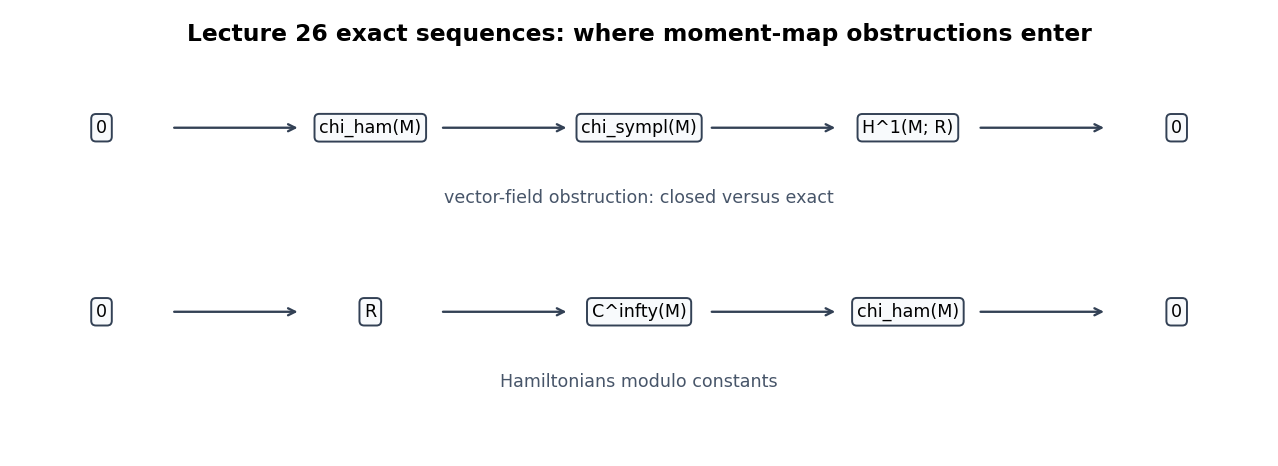

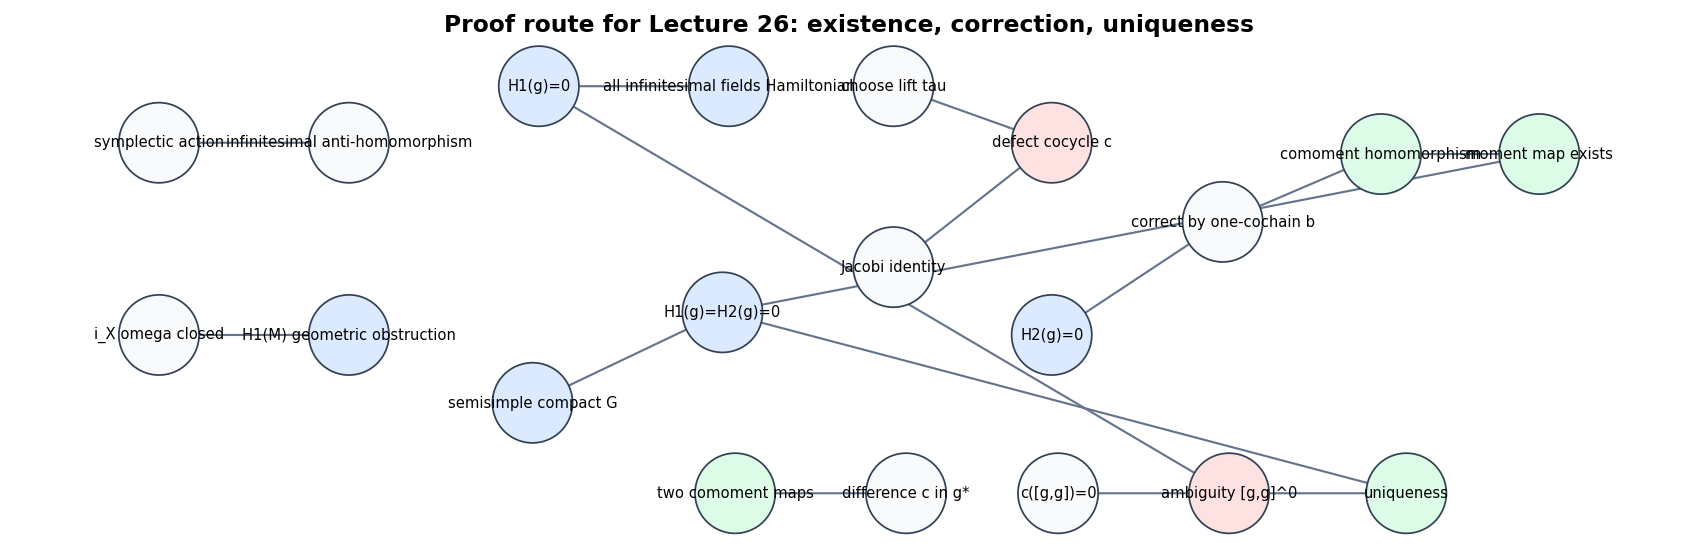

{'nodes': 20, 'edges': 15, 'isolates': []}


In [3]:
# Exact-sequence diagram and proof dependency route.
plt.rcParams.update({"figure.dpi": 140, "font.size": 9})

fig, ax = plt.subplots(figsize=(9.2, 3.4))
ax.axis("off")
rows = [
    (["0", "chi_ham(M)", "chi_sympl(M)", "H^1(M; R)", "0"], "vector-field obstruction: closed versus exact"),
    (["0", "R", "C^infty(M)", "chi_ham(M)", "0"], "Hamiltonians modulo constants"),
]
for r, (labels, caption) in enumerate(rows):
    y = 0.74 - 0.42 * r
    xs = np.linspace(0.07, 0.93, len(labels))
    for i, (x, label) in enumerate(zip(xs, labels)):
        box = dict(boxstyle="round,pad=0.27", facecolor="#f8fafc", edgecolor="#334155", linewidth=1.0)
        ax.text(x, y, label, ha="center", va="center", bbox=box)
        if i < len(labels) - 1:
            ax.annotate("", xy=(xs[i+1] - 0.055, y), xytext=(x + 0.055, y), arrowprops=dict(arrowstyle="->", lw=1.2, color="#334155"))
    ax.text(0.5, y - 0.16, caption, ha="center", va="center", color="#475569")
ax.text(0.5, 0.98, "Lecture 26 exact sequences: where moment-map obstructions enter", ha="center", va="top", fontsize=12, weight="bold")
fig.tight_layout()
exact_path = FIG_DIR / "lie-algebra-exact-sequences.png"
fig.savefig(exact_path, bbox_inches="tight")
plt.close(fig)

G = nx.DiGraph()
edges = [
    ("symplectic action", "infinitesimal anti-homomorphism"),
    ("i_X omega closed", "H1(M) geometric obstruction"),
    ("H1(g)=0", "all infinitesimal fields Hamiltonian"),
    ("choose lift tau", "defect cocycle c"),
    ("Jacobi identity", "defect cocycle c"),
    ("H2(g)=0", "correct by one-cochain b"),
    ("correct by one-cochain b", "comoment homomorphism"),
    ("comoment homomorphism", "moment map exists"),
    ("two comoment maps", "difference c in g*"),
    ("c([g,g])=0", "ambiguity [g,g]^0"),
    ("H1(g)=0", "ambiguity [g,g]^0"),
    ("ambiguity [g,g]^0", "uniqueness"),
    ("semisimple compact G", "H1(g)=H2(g)=0"),
    ("H1(g)=H2(g)=0", "moment map exists"),
    ("H1(g)=H2(g)=0", "uniqueness"),
]
G.add_edges_from(edges)
pos = {
    "symplectic action": (0.0, 2.0), "infinitesimal anti-homomorphism": (1.5, 2.0),
    "i_X omega closed": (0.0, 1.15), "H1(M) geometric obstruction": (1.5, 1.15),
    "H1(g)=0": (3.0, 2.25), "all infinitesimal fields Hamiltonian": (4.5, 2.25),
    "choose lift tau": (5.8, 2.25), "Jacobi identity": (5.8, 1.45), "defect cocycle c": (7.05, 2.0),
    "H2(g)=0": (7.05, 1.15), "correct by one-cochain b": (8.4, 1.65),
    "comoment homomorphism": (9.65, 1.95), "moment map exists": (10.9, 1.95),
    "two comoment maps": (4.55, 0.45), "difference c in g*": (5.9, 0.45),
    "c([g,g])=0": (7.1, 0.45), "ambiguity [g,g]^0": (8.45, 0.45), "uniqueness": (9.85, 0.45),
    "semisimple compact G": (2.95, 0.85), "H1(g)=H2(g)=0": (4.45, 1.25),
}
fig, ax = plt.subplots(figsize=(12.2, 4.0))
ax.axis("off")
colors = []
for node in G.nodes:
    if "H" in node or "semisimple" in node:
        colors.append("#dbeafe")
    elif "moment" in node or "uniqueness" in node:
        colors.append("#dcfce7")
    elif "obstruction" in node or "defect" in node or "ambiguity" in node:
        colors.append("#fee2e2")
    else:
        colors.append("#f8fafc")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=12, width=1.1, edge_color="#64748b")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=1700, edgecolors="#334155", linewidths=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=7.6)
ax.set_title("Proof route for Lecture 26: existence, correction, uniqueness", fontsize=12, weight="bold")
fig.tight_layout()
route_path = FIG_DIR / "proof-dependency-route.png"
fig.savefig(route_path, bbox_inches="tight")
plt.close(fig)

display_artifact(rel(exact_path), width=820)
display_artifact(rel(route_path), width=900)

route_check = {"nodes": G.number_of_nodes(), "edges": G.number_of_edges(), "isolates": list(nx.isolates(G))}
print(route_check)

## Chevalley-Eilenberg Ledger for `H1` and `H2`

The lecture uses only the first two pieces of Lie algebra cohomology. In coordinates, the bracket supplies matrices for the differential. The next cell computes those matrices for three small models:

- `t2`: an abelian two-dimensional algebra, modeling the non-semisimple torus case.
- `u2_like`: a compact algebra with a central direction plus an `su2` bracket part.
- `su2`: a semisimple model where Whitehead's lemmas predict `H1 = H2 = 0`.

The point is not to prove Whitehead's lemmas by computation. It is to make the obstruction bookkeeping visible: `H1` measures missing commutators, and `H2` measures whether the lift defect can be absorbed by constants.

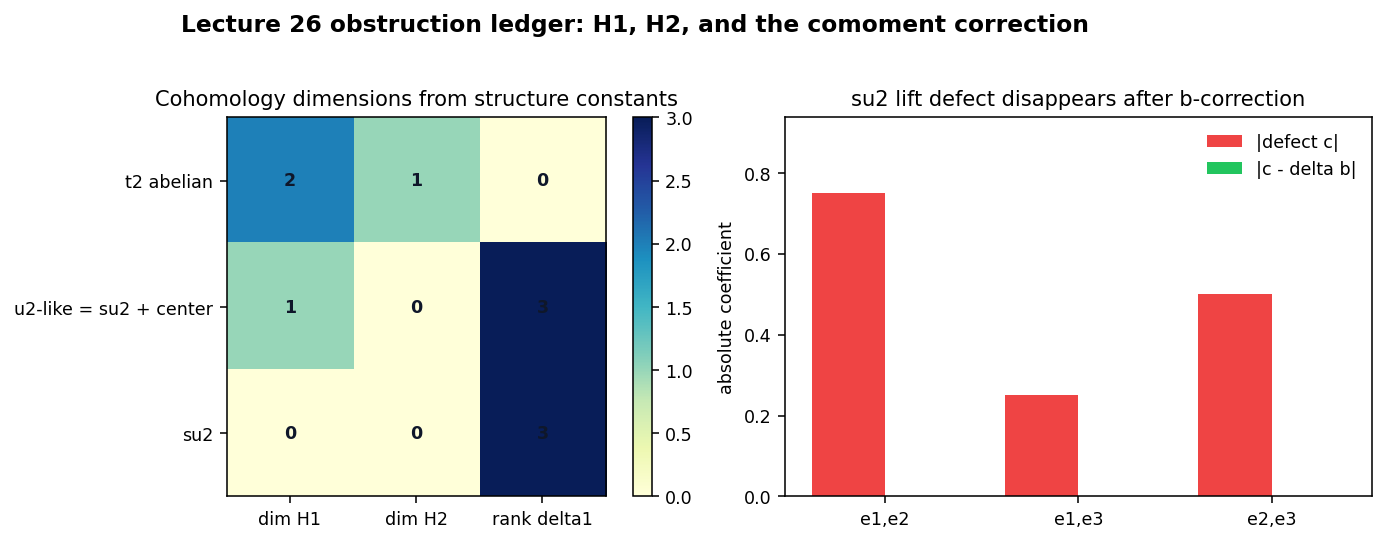

{
  "summaries": [
    {
      "name": "t2 abelian",
      "dimension_g": 2,
      "dim_C2": 1,
      "rank_delta1": 0,
      "rank_delta2": 0,
      "dim_H1": 2,
      "dim_H2": 1,
      "pairs": [
        [
          0,
          1
        ]
      ]
    },
    {
      "name": "u2-like = su2 + center",
      "dimension_g": 4,
      "dim_C2": 6,
      "rank_delta1": 3,
      "rank_delta2": 3,
      "dim_H1": 1,
      "dim_H2": 0,
      "pairs": [
        [
          0,
          1
        ],
        [
          0,
          2
        ],
        [
          0,
          3
        ],
        [
          1,
          2
        ],
        [
          1,
          3
        ],
        [
          2,
          3
        ]
      ]
    },
    {
      "name": "su2",
      "dimension_g": 3,
      "dim_C2": 3,
      "rank_delta1": 3,
      "rank_delta2": 0,
      "dim_H1": 0,
      "dim_H2": 0,
      "pairs": [
        [
          0,
          1
        ],
        [
          0,
          2
     

In [4]:
def ce_matrices(structure):
    """Return delta1:C1->C2 and delta2:C2->C3 for a finite-dimensional Lie algebra."""
    C = np.asarray(structure, dtype=float)  # C[k,i,j] coefficient of e_k in [e_i,e_j]
    n = C.shape[0]
    pairs = list(itertools.combinations(range(n), 2))
    triples = list(itertools.combinations(range(n), 3))
    d1 = np.zeros((len(pairs), n))
    for row, (i, j) in enumerate(pairs):
        d1[row, :] = -C[:, i, j]
    d2 = np.zeros((len(triples), len(pairs)))
    pair_index = {p: a for a, p in enumerate(pairs)}

    def add_pair(row, a, b, coeff):
        if a == b:
            return
        if a < b:
            d2[row, pair_index[(a, b)]] += coeff
        else:
            d2[row, pair_index[(b, a)]] -= coeff

    for row, (i, j, k) in enumerate(triples):
        # delta c(i,j,k) = -c([i,j],k) + c([i,k],j) - c([j,k],i)
        for a in range(n):
            add_pair(row, a, k, -C[a, i, j])
            add_pair(row, a, j, C[a, i, k])
            add_pair(row, a, i, -C[a, j, k])
    return d1, d2, pairs, triples


def rank(A, tol=1e-10):
    return int(np.linalg.matrix_rank(A, tol=tol)) if A.size else 0


def cohomology_summary(name, structure):
    d1, d2, pairs, triples = ce_matrices(structure)
    n = structure.shape[0]
    c1_dim = n
    c2_dim = len(pairs)
    h1_dim = c1_dim - rank(d1)
    h2_dim = (c2_dim - rank(d2)) - rank(d1)
    return {
        "name": name,
        "dimension_g": n,
        "dim_C2": c2_dim,
        "rank_delta1": rank(d1),
        "rank_delta2": rank(d2),
        "dim_H1": int(h1_dim),
        "dim_H2": int(h2_dim),
        "pairs": pairs,
    }


def bracket_tensor(n, brackets):
    C = np.zeros((n, n, n))
    for (i, j), terms in brackets.items():
        for k, value in terms.items():
            C[k, i, j] += value
            C[k, j, i] -= value
    return C

# Basis for su2-like part: [e1,e2]=e3, [e2,e3]=e1, [e3,e1]=e2.
t2 = bracket_tensor(2, {})
su2 = bracket_tensor(3, {(0, 1): {2: 1}, (1, 2): {0: 1}, (2, 0): {1: 1}})
u2_like = bracket_tensor(4, {(0, 1): {2: 1}, (1, 2): {0: 1}, (2, 0): {1: 1}})  # e3 is central
summaries = [cohomology_summary("t2 abelian", t2), cohomology_summary("u2-like = su2 + center", u2_like), cohomology_summary("su2", su2)]

# A concrete lift-defect correction in su2: every 2-cochain is a coboundary here.
d1_su2, d2_su2, pairs_su2, _ = ce_matrices(su2)
defect = np.array([0.75, -0.25, 0.5])
b_solution, *_ = np.linalg.lstsq(d1_su2, defect, rcond=None)
corrected_residual = defect - d1_su2 @ b_solution

fig, axs = plt.subplots(1, 2, figsize=(10.8, 3.7), gridspec_kw={"width_ratios": [1.15, 1]})
labels = [s["name"] for s in summaries]
heat = np.array([[s["dim_H1"], s["dim_H2"], s["rank_delta1"]] for s in summaries], dtype=float)
im = axs[0].imshow(heat, cmap="YlGnBu", vmin=0)
axs[0].set_xticks(range(3), ["dim H1", "dim H2", "rank delta1"])
axs[0].set_yticks(range(len(labels)), labels)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        axs[0].text(j, i, f"{heat[i,j]:.0f}", ha="center", va="center", color="#0f172a", weight="bold")
axs[0].set_title("Cohomology dimensions from structure constants")
fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)

x = np.arange(len(pairs_su2))
width = 0.38
axs[1].bar(x - width/2, np.abs(defect), width, label="|defect c|", color="#ef4444")
axs[1].bar(x + width/2, np.abs(corrected_residual), width, label="|c - delta b|", color="#22c55e")
axs[1].set_xticks(x, [f"e{i+1},e{j+1}" for i, j in pairs_su2])
axs[1].set_ylim(0, max(np.abs(defect)) * 1.25)
axs[1].set_title("su2 lift defect disappears after b-correction")
axs[1].legend(frameon=False)
axs[1].set_ylabel("absolute coefficient")
fig.suptitle("Lecture 26 obstruction ledger: H1, H2, and the comoment correction", y=1.03, fontsize=12, weight="bold")
fig.tight_layout()
ledger_path = FIG_DIR / "cohomology-obstruction-ledger.png"
fig.savefig(ledger_path, bbox_inches="tight")
plt.close(fig)

cohomology_checks = {
    "summaries": summaries,
    "su2_defect_pairs": [list(p) for p in pairs_su2],
    "su2_defect": defect.round(12).tolist(),
    "su2_correcting_one_cochain_b": b_solution.round(12).tolist(),
    "su2_corrected_residual_norm": float(np.linalg.norm(corrected_residual)),
    "expected": {"su2_dim_H1": 0, "su2_dim_H2": 0, "t2_dim_H1": 2, "t2_dim_H2": 1},
}
(CHECK_DIR / "cohomology-checks.json").write_text(json.dumps(cohomology_checks, indent=2), encoding="utf-8")

assert summaries[2]["dim_H1"] == 0 and summaries[2]["dim_H2"] == 0
assert summaries[0]["dim_H1"] == 2 and summaries[0]["dim_H2"] == 1
assert np.linalg.norm(corrected_residual) < 1e-12

display_artifact(rel(ledger_path), width=850)
print(json.dumps(cohomology_checks, indent=2)[:1200] + "\n...")

## Existence: What the `H2` Correction Does

The proof begins with an arbitrary vector-space lift `tau`. It already gives Hamiltonian functions for the infinitesimal vector fields, but it may fail to preserve brackets. That failure is the two-cochain `c`. The Jacobi identity makes `c` closed. If `H2(g; R)=0`, then `c=delta b`; adding the constant `b(X)` to each Hamiltonian does not change its vector field, but it does repair the bracket relation.

This is the key computational lesson: **existence is not just finding Hamiltonians one at a time; it is making the choices compatible with the Lie bracket.**

## The Torus Counterexample: Closed Does Not Mean Exact

The lecture ends with a sharp warning. On the symplectic torus with coordinates `(theta1, theta2)` and form `dtheta1 wedge dtheta2`, rotation in the `theta1` direction has generator `X = d/dtheta1`. Its contraction is `i_X omega = dtheta2`. This one-form is closed, so the action is symplectic, but its period around the `theta2` cycle is `2*pi`. An exact one-form would have zero period around every closed loop.

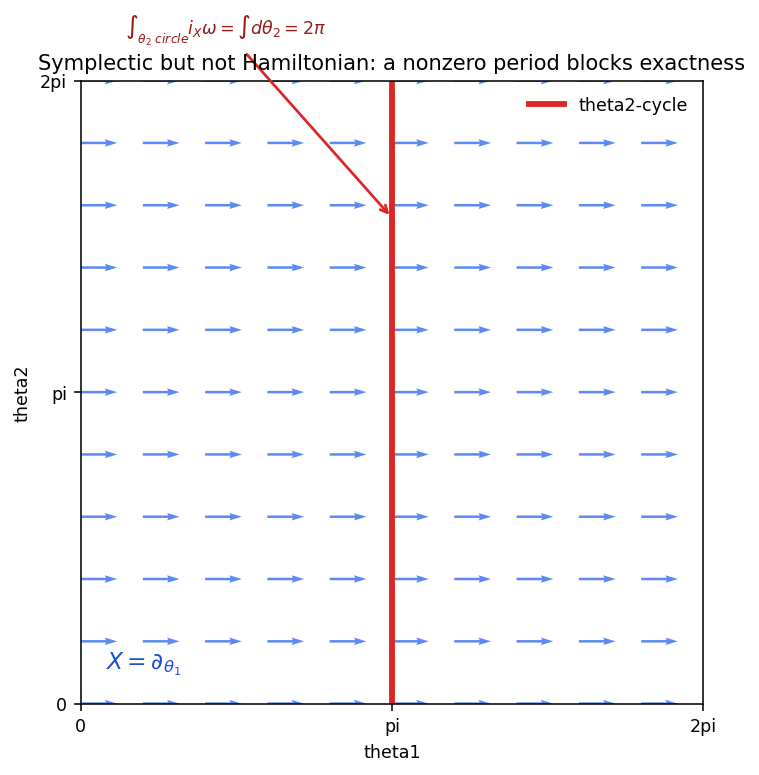

{'one_form': 'i_{d/dtheta1}(dtheta1 wedge dtheta2) = dtheta2', 'period_over_theta2_cycle': 6.283185307179586, 'exact_forms_have_zero_closed_periods': True, 'hamiltonian_possible': False}


In [5]:
theta = np.linspace(0, 2 * np.pi, 17)
x, y = np.meshgrid(np.linspace(0, 2 * np.pi, 11), np.linspace(0, 2 * np.pi, 11))
u = np.ones_like(x)
v = np.zeros_like(y)
period_theta2 = float(2 * np.pi)

fig, ax = plt.subplots(figsize=(6.6, 5.6))
ax.quiver(x, y, u, v, color="#2563eb", angles="xy", scale_units="xy", scale=2.7, width=0.004, alpha=0.75)
ax.plot(np.full_like(theta, np.pi), theta, color="#dc2626", lw=3, label=r"theta2-cycle")
ax.annotate(r"$\int_{\theta_2\ circle} i_X\omega = \int d\theta_2 = 2\pi$", xy=(np.pi, 4.9), xytext=(0.45, 6.75),
            arrowprops=dict(arrowstyle="->", color="#dc2626", lw=1.4), color="#991b1b")
ax.text(0.25, 0.35, r"$X=\partial_{\theta_1}$", color="#1d4ed8", fontsize=12, weight="bold")
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(0, 2 * np.pi)
ax.set_aspect("equal")
ax.set_xticks([0, np.pi, 2*np.pi], ["0", "pi", "2pi"])
ax.set_yticks([0, np.pi, 2*np.pi], ["0", "pi", "2pi"])
ax.set_xlabel(r"theta1")
ax.set_ylabel(r"theta2")
ax.set_title("Symplectic but not Hamiltonian: a nonzero period blocks exactness")
ax.legend(loc="upper right", frameon=False)
fig.tight_layout()
torus_path = FIG_DIR / "torus-nonhamiltonian-obstruction.png"
fig.savefig(torus_path, bbox_inches="tight")
plt.close(fig)

torus_check = {
    "one_form": "i_{d/dtheta1}(dtheta1 wedge dtheta2) = dtheta2",
    "period_over_theta2_cycle": period_theta2,
    "exact_forms_have_zero_closed_periods": True,
    "hamiltonian_possible": False,
}
(CHECK_DIR / "torus-obstruction.json").write_text(json.dumps(torus_check, indent=2), encoding="utf-8")
assert abs(period_theta2 - 2 * math.pi) < 1e-12

display_artifact(rel(torus_path), width=620)
print(torus_check)

## Uniqueness: The Ambiguity Space `[g,g]^0`

Once a moment map exists, adding a constant element of `g*` does not change the Hamiltonian vector fields. Equivariance/comoment compatibility removes exactly the constants that do not vanish on brackets. The allowable shifts are therefore the annihilator of the commutator ideal.

The three panels below encode the extremes named in the lecture and a middle case. A semisimple algebra has no ambiguity. An abelian algebra has only zero brackets, so every constant is allowed. A compact algebra with a one-dimensional center has a one-dimensional ambiguity line.

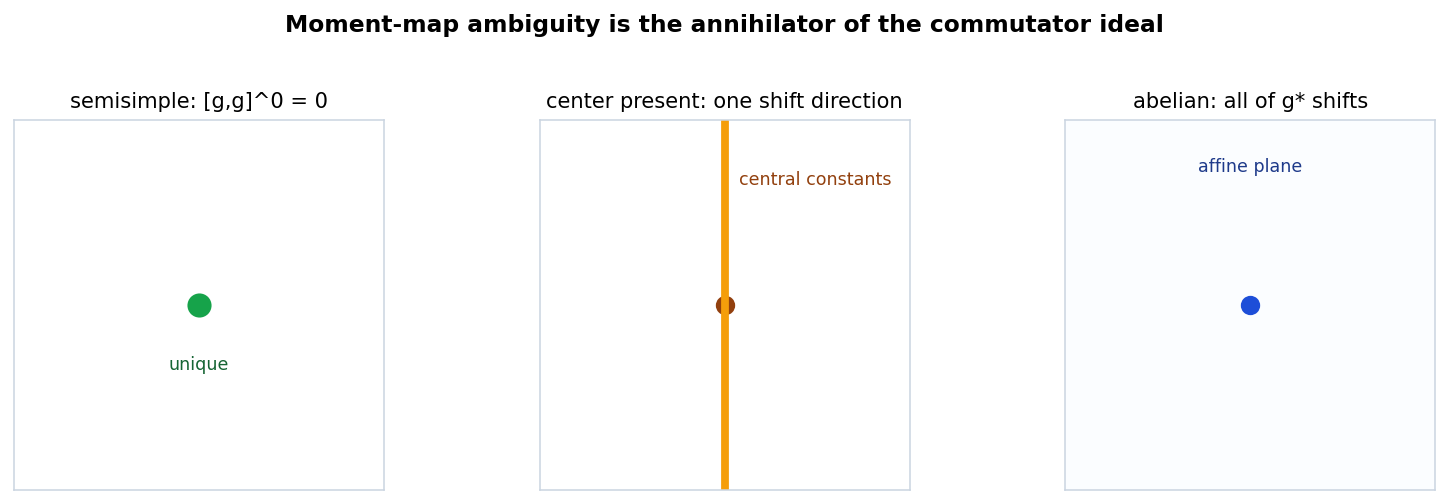

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'audit_expansion': 'Lecture 26 uniqueness check: this record verifies that the visual ambiguity dimensions match [g,g]^0 and that adding a constant to a moment map changes values but not derivatives.', 'ambiguity_dimensions': {'semisimple_su2': 0, 'u2_like_center': 1, 'abelian_t2': 2}, 'interpretation': {'semisimple_su2': '[g,g]=g, so the annihilator is zero and the moment map is unique when it exists.', 'u2_like_center': 'the central direction is not a commutator, so one constant shift remains invisible to Hamiltonian vector fields.', 'abelian_t2': 'all brackets vanish, so every element of g* is an allowed constant shift.'}, 'constant_shift_gradient_difference': 3.2862601528904634e-14}


In [6]:
fig, axs = plt.subplots(1, 3, figsize=(11.4, 3.4))

# semisimple: point
axs[0].scatter([0], [0], s=130, color="#16a34a")
axs[0].set_title("semisimple: [g,g]^0 = 0")
axs[0].set_xlim(-1, 1); axs[0].set_ylim(-1, 1)
axs[0].text(0, -0.35, "unique", ha="center", color="#166534")

# u2-like: line
axs[1].plot([0, 0], [-1, 1], color="#f59e0b", lw=4)
axs[1].scatter([0], [0], s=80, color="#92400e")
axs[1].set_title("center present: one shift direction")
axs[1].set_xlim(-1, 1); axs[1].set_ylim(-1, 1)
axs[1].text(0.08, 0.65, "central constants", color="#92400e")

# abelian: plane
xx, yy = np.meshgrid(np.linspace(-1, 1, 2), np.linspace(-1, 1, 2))
axs[2].imshow(np.ones((2,2)), extent=(-1,1,-1,1), origin="lower", cmap="Blues", alpha=0.38)
axs[2].scatter([0], [0], s=80, color="#1d4ed8")
axs[2].set_title("abelian: all of g* shifts")
axs[2].set_xlim(-1, 1); axs[2].set_ylim(-1, 1)
axs[2].text(0, 0.72, "affine plane", ha="center", color="#1e3a8a")

for ax in axs:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[:].set_color("#cbd5e1")
fig.suptitle("Moment-map ambiguity is the annihilator of the commutator ideal", y=1.04, fontsize=12, weight="bold")
fig.tight_layout()
unique_path = FIG_DIR / "uniqueness-affine-space.png"
fig.savefig(unique_path, bbox_inches="tight")
plt.close(fig)

# Interactive constant-shift lab for the circle action on C.
grid = np.linspace(-2.0, 2.0, 90)
X, Y = np.meshgrid(grid, grid)
base_mu = -0.5 * (X**2 + Y**2)
cs = [-1.0, 0.0, 1.0]
fig_html = go.Figure()
for idx, c in enumerate(cs):
    fig_html.add_trace(go.Contour(x=grid, y=grid, z=base_mu + c, contours_coloring="heatmap", visible=(idx == 1),
                                  colorbar=dict(title="mu+c") if idx == 1 else None,
                                  name=f"c={c:+.1f}"))
steps = []
for idx, c in enumerate(cs):
    visible = [False] * len(cs)
    visible[idx] = True
    steps.append(dict(method="update", args=[{"visible": visible}, {"title": f"Constant shift c={c:+.1f}: d(mu+c)=dmu"}], label=f"c={c:+.1f}"))
fig_html.update_layout(
    title="Constant shifts move moment values but not Hamiltonian vector fields",
    xaxis_title="x", yaxis_title="y", width=720, height=560,
    sliders=[dict(active=1, currentvalue={"prefix": "shift "}, steps=steps)],
)
html_path = HTML_DIR / "moment-map-constant-shift-lab.html"
fig_html.write_html(html_path, include_plotlyjs="cdn")

grad_base = np.gradient(base_mu, grid, grid)
grad_shift = np.gradient(base_mu + 7.0, grid, grid)
gradient_shift_difference = float(max(np.max(np.abs(a - b)) for a, b in zip(grad_base, grad_shift)))
uniqueness_check = {
    "audit_expansion": "Lecture 26 uniqueness check: this record verifies that the visual ambiguity dimensions match [g,g]^0 and that adding a constant to a moment map changes values but not derivatives.",
    "ambiguity_dimensions": {"semisimple_su2": 0, "u2_like_center": 1, "abelian_t2": 2},
    "interpretation": {
        "semisimple_su2": "[g,g]=g, so the annihilator is zero and the moment map is unique when it exists.",
        "u2_like_center": "the central direction is not a commutator, so one constant shift remains invisible to Hamiltonian vector fields.",
        "abelian_t2": "all brackets vanish, so every element of g* is an allowed constant shift."
    },
    "constant_shift_gradient_difference": gradient_shift_difference,
}
(CHECK_DIR / "uniqueness-checks.json").write_text(json.dumps(uniqueness_check, indent=2), encoding="utf-8")
assert gradient_shift_difference < 1e-12

display_artifact(rel(unique_path), width=850)
display_artifact(rel(html_path), width=760, height=560)
print(uniqueness_check)

## Takeaways and Exploration Prompt

- `H1(M)` separates symplectic vector fields from Hamiltonian vector fields.
- `H1(g)` forces the infinitesimal action into Hamiltonian vector fields when the acting algebra is generated by brackets.
- `H2(g)` removes the bracket defect of an arbitrary Hamiltonian lift.
- Compact semisimple groups sit in the clean case: existence and uniqueness.
- Commutative groups sit in the delicate case: existence may fail, and even when it holds constants are unconstrained.

**Try next.** Replace the torus vector field by `a d/dtheta1 + b d/dtheta2`. The contraction has periods `2*pi*a` and `-2*pi*b` on the two fundamental cycles. Predict from those two numbers whether the vector field can be Hamiltonian on `T2`.

In [7]:
artifact_paths = [
    rel(FIG_DIR / "proof-dependency-route.png"),
    rel(FIG_DIR / "lie-algebra-exact-sequences.png"),
    rel(FIG_DIR / "cohomology-obstruction-ledger.png"),
    rel(FIG_DIR / "torus-nonhamiltonian-obstruction.png"),
    rel(FIG_DIR / "uniqueness-affine-space.png"),
    rel(HTML_DIR / "moment-map-constant-shift-lab.html"),
    rel(CHECK_DIR / "source-span.json"),
    rel(CHECK_DIR / "visual-storyboard.json"),
    rel(CHECK_DIR / "cohomology-checks.json"),
    rel(CHECK_DIR / "torus-obstruction.json"),
    rel(CHECK_DIR / "uniqueness-checks.json"),
]

for relative in artifact_paths:
    path = BOOK_ROOT / relative
    assert path.exists(), f"missing artifact: {relative}"
    assert path.stat().st_size > 200, f"artifact too small: {relative}"

final_sanity = {
    "passed": True,
    "status": "passed",
    "source_span_used": SOURCE_SPAN,
    "storyboard_items_implemented": [item["concept"] for item in STORYBOARD["visual_sequence"]],
    "artifacts": artifact_paths,
    "checks": {
        "proof_route": route_check,
        "cohomology": {
            "su2_dim_H1": summaries[2]["dim_H1"],
            "su2_dim_H2": summaries[2]["dim_H2"],
            "t2_dim_H1": summaries[0]["dim_H1"],
            "t2_dim_H2": summaries[0]["dim_H2"],
            "su2_corrected_residual_norm": cohomology_checks["su2_corrected_residual_norm"],
        },
        "torus_period_over_theta2_cycle": period_theta2,
        "constant_shift_gradient_difference": gradient_shift_difference,
    },
}
(CHECK_DIR / "final-sanity.json").write_text(json.dumps(final_sanity, indent=2), encoding="utf-8")
print(json.dumps(final_sanity, indent=2))

{
  "passed": true,
  "status": "passed",
  "source_span_used": {
    "lecture": "Lecture 26",
    "title": "Existence and Uniqueness of Moment Maps",
    "printed_pages_read": "162-166",
    "physical_pdf_pages_read": "172-176",
    "source_map_note": "Direct pdftotext verification showed the inventory range 176-181 begins at printed page 166 and continues into Lecture 27.",
    "sections": [
      "26.1 Lie Algebras of Vector Fields",
      "26.2 Lie Algebra Cohomology",
      "26.3 Existence of Moment Maps",
      "26.4 Uniqueness of Moment Maps"
    ]
  },
  "storyboard_items_implemented": [
    "exact sequences and proof route",
    "closed versus exact vector-field obstruction",
    "Chevalley-Eilenberg H1/H2 ledger",
    "non-Hamiltonian torus action",
    "uniqueness up to [g,g]^0",
    "constant shift lab"
  ],
  "artifacts": [
    "artifacts/lecture-26/figures/proof-dependency-route.png",
    "artifacts/lecture-26/figures/lie-algebra-exact-sequences.png",
    "artifacts/lectu